In [ ]:
import os
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy.stats import chi2
from scipy.spatial.distance import pdist, squareform
from pathlib import Path

warnings.filterwarnings('ignore')
os.environ['CUDA_VISIBLE_DEVICES'] = '5'
sys.path.append(r'/import/home2/share/yqzeng/MacSGP/codes')

mpl.rcParams.update({
    'font.family':        'Helvetica',
    'font.size':          7,
    'axes.titlesize':     8,
    'axes.labelsize':     7,
    'xtick.labelsize':    6.5,
    'ytick.labelsize':    6.5,
    'axes.linewidth':     0.5,
    'xtick.major.width':  0.5,
    'ytick.major.width':  0.5,
    'xtick.major.size':   2.5,
    'ytick.major.size':   2.5,
    'pdf.fonttype':       42,
    'ps.fonttype':        42,
    'savefig.dpi':        300,
    'figure.dpi':         150,
})

PERM_PATH   = '/import/home2/share/yqzeng/MacSGP/results/permutation/mouse_brain'
SAVE_PATH   = '/import/home2/share/yqzeng/MacSGP/Results/Mouth_brain_visium'
OUT_DIR     = Path('/import/home2/share/yqzeng/MacSGP/revision/vis/1.6')

REAL_DATA_CSV    = os.path.join(PERM_PATH, 'real.csv')
PROPORTION_CSV   = os.path.join(PERM_PATH, 'proportion.csv')

NULL_PVAL_V3     = str(OUT_DIR / 'null_distribution_dist.csv')
NULL_TSTAT_V3    = str(OUT_DIR / 'null_distribution_dist_Tstat.csv')
NULL_KERNEL_V3   = str(OUT_DIR / 'null_distribution_dist_per_kernel.csv')

NULL_TSTAT_V2    = str(OUT_DIR / 'null_distribution_Tstat.csv')

print('Environment ready.')

Environment ready.


In [ ]:
def acat_combine_single(pvals, weights=None):
    '''
    Aggregated Cauchy Association Test:
    T_ACAT = sum(w_k * tan((0.5 - p_k) * pi))
    '''
    pvals   = np.clip(np.asarray(pvals, dtype=np.float64), 1e-15, 0.99)
    weights = np.ones(len(pvals)) / len(pvals) if weights is None else weights
    T       = np.sum(weights * np.tan((0.5 - pvals) * np.pi))
    return 0.5 - np.arctan(T) / np.pi, T

def select_spots(proportion_vec, method='threshold', threshold=0.0,
                 quantile=0.5, min_spots=30):
    '''
    method: 'threshold' | 'quantile' | 'topk' | 'nonzero' | 'adaptive'
    '''
    n = len(proportion_vec)

    if method == 'nonzero':
        mask = proportion_vec > 0
    elif method == 'threshold':
        mask = proportion_vec > threshold
    elif method == 'quantile':
        nz = proportion_vec[proportion_vec > 0]
        mask = proportion_vec >= np.quantile(nz, quantile) if len(nz) >= min_spots else proportion_vec > 0
    elif method == 'topk':
        k    = max(int(n * quantile), min_spots)
        idx  = np.argsort(proportion_vec)[::-1][:k]
        mask = np.zeros(n, dtype=bool); mask[idx] = True
    elif method == 'adaptive':
        best_thresh, best_var = 0.0, -1
        for t in np.linspace(proportion_vec.min(), proportion_vec.max(), 200):
            c0, c1 = proportion_vec[proportion_vec <= t], proportion_vec[proportion_vec > t]
            if len(c0) == 0 or len(c1) == 0: continue
            bv = (len(c0)/n) * (len(c1)/n) * (c0.mean() - c1.mean())**2
            if bv > best_var: best_var, best_thresh = bv, t
        mask = proportion_vec > best_thresh
    else:
        raise ValueError(f'Unknown method: {method}')

    if mask.sum() < min_spots: mask = proportion_vec > 0
    if mask.sum() < min_spots: mask = np.ones(n, dtype=bool)
    return mask


print('Helper functions loaded.')

Helper functions loaded.


In [ ]:
from scipy.linalg import eigvalsh
from scipy.integrate import quad

def _center_kernel(K):
    row_means = K.mean(axis=1, keepdims=True)
    col_means = K.mean(axis=0, keepdims=True)
    return K - row_means - col_means + K.mean()


def build_dist_kernel(sub_c, kernel_type='gaussian', lker=1,
                      dist_quantiles=(0.6, 0.8, 1.0),
                      D=None, center=True):
    if kernel_type == 'gaussian_coord':
        coord_q_levels = np.arange(0.2, 1.01, 0.2)            # [0.2, 0.4, 0.6, 0.8, 1.0]
        X = np.zeros_like(sub_c)
        for dim in range(sub_c.shape[1]):
            col = sub_c[:, dim]
            l_d = max(np.quantile(np.abs(col), coord_q_levels[lker - 1]), 1e-15)
            X[:, dim] = np.exp(-col**2 / (2 * l_d**2))
        X = X - X.mean(axis=0)                                 
        XtX = X.T @ X
        if np.linalg.matrix_rank(XtX) < XtX.shape[0]:
            K = np.zeros((len(sub_c), len(sub_c)))
        else:
            K = X @ np.linalg.solve(XtX, X.T)                
        l_rep = float(np.nan)                                 
        return (_center_kernel(K) if center else K), l_rep

    if D is None:
        D = squareform(pdist(sub_c, metric='euclidean'))

    d_vals = D[np.triu_indices_from(D, k=1)]
    if lker == 1:
        coef_scale = 0.9
    else:
        coef_scale = 4
    l = max(np.quantile(d_vals, dist_quantiles[lker - 1]), 1e-15) * np.sqrt(coef_scale)

    if   kernel_type == 'gaussian':
        K = np.exp(-D**2 / (2 * l**2))
    elif kernel_type == 'exponential':
        K = np.exp(-D / l)
    elif kernel_type == 'cosine':
        K = np.cos(2 * np.pi * D / l)
    elif kernel_type == 'cauchy':
        # K_ij = 1 / (1 + d^2 / (2 * l^2))
        K = 1.0 / (1.0 + D**2 / (2 * l**2))
    elif kernel_type == 'periodic':
        # K_ij = exp(-sin(pi * d)^2 / (2 * l^2))
        K = np.exp(-np.sin(np.pi * D)**2 / (2 * l**2))
    else:
        raise ValueError(f'Unknown kernel_type: {kernel_type}')

    return (_center_kernel(K) if center else K), l

def davies_pval(q, lambdas, epsabs=1e-6, epsrel=1e-6):
    lam = np.asarray(lambdas, dtype=np.float64)
    lam = lam[np.abs(lam) > 1e-10 * max(np.abs(lam).max(), 1.0)]
    if len(lam) == 0 or q <= 0:
        return 1.0

    def _integrand(u):
        theta   = 0.5 * np.sum(np.arctan(lam * u)) - 0.5 * q * u
        log_rho = 0.25 * np.sum(np.log1p(lam**2 * u**2))
        return np.sin(theta) * np.exp(-log_rho) / u

    lam_pos = lam[lam > 0]
    u_max   = (50.0 / lam_pos.max()) if len(lam_pos) > 0 else 1e4

    try:
        val, _ = quad(_integrand, 1e-12, u_max,
                      limit=2000, epsabs=epsabs, epsrel=epsrel)
        p = float(np.clip(0.5 + val / np.pi, 0.0, 1.0))
    except Exception:
        p = 1.0
    return p

def sparkx_dist_single_kernel(factor_vec, K_c, method='davies'):
    f = np.asarray(factor_vec, dtype=np.float64)
    T = float(f @ K_c @ f)

    if T <= 0:
        return T, 1.0

    if method == 'davies':
        lambdas = eigvalsh(K_c)
        pval    = davies_pval(T, lambdas)
    else:
        trK  = np.trace(K_c)
        trK2 = np.sum(K_c ** 2)
        if trK <= 1e-15 or trK2 <= 1e-15:
            return T, 1.0
        c    = trK2 / trK
        nu   = trK ** 2 / trK2
        pval = float(np.clip(1.0 - chi2.cdf(T / c, df=nu), 0.0, 1.0))

    return T, pval
def sparkx_dist_celltype(factor_vec, coords, proportion_vec,
                          filter_method='threshold', filter_threshold=0.0,
                          filter_quantile=0.5, min_spots=30,
                          kernel_types=('gaussian', 'exponential', 'cosine'),
                          n_lker=5,
                          dist_quantiles=(0.05, 0.1, 0.2, 0.4, 0.6),
                          method='davies',
                          weight_by_proportion=False):
    mask   = select_spots(proportion_vec, method=filter_method,
                          threshold=filter_threshold, quantile=filter_quantile,
                          min_spots=min_spots)
    sub_f  = factor_vec[mask].copy()
    sub_c  = coords[mask].copy()
    n_used = int(mask.sum())

    n_kernels = len(kernel_types) * n_lker
    if np.std(sub_f) < 1e-15 or n_used < 10:
        return 1.0, 0.0, n_used, np.ones(n_kernels)

    sub_f = (sub_f - sub_f.mean()) / max(sub_f.std(), 1e-15)
    sub_c = (sub_c - sub_c.mean(axis=0)) / np.maximum(sub_c.std(axis=0), 1e-15)

    w = proportion_vec[mask] if weight_by_proportion else None

    pvals = []
    for ktype in kernel_types:
        for k in range(1, n_lker + 1):
            if weight_by_proportion:
                K_raw, _ = build_dist_kernel(sub_c, kernel_type=ktype, lker=k,
                                             dist_quantiles=dist_quantiles,
                                             center=False)
                K_c = _center_kernel(np.outer(w, w) * K_raw)
            else:
                K_c, _ = build_dist_kernel(sub_c, kernel_type=ktype, lker=k,
                                           dist_quantiles=dist_quantiles)
            _, p = sparkx_dist_single_kernel(sub_f, K_c, method=method)
            pvals.append(p)

    combined_pval, T_acat = acat_combine_single(np.array(pvals))
    return combined_pval, T_acat, n_used, np.array(pvals)


print('Distance kernel functions loaded (Davies + Satterthwaite + proportion weighting).')


Distance kernel functions loaded (Davies + Satterthwaite + proportion weighting).


In [ ]:
def run_null_distribution_dist(
    data_dir, proportion_path, n_perm=100,
    filter_method='threshold', filter_threshold=0.0,
    filter_quantile=0.5, min_spots=30,
    kernel_types=('gaussian', 'exponential', 'cosine'),
    n_lker=3,
    dist_quantiles=(0.05, 0.1, 0.2, 0.4, 0.6),
    output_path='null_distribution_dist.csv',
    method='satterthwaite',
    celltypes=None,
    weight_by_proportion=False,
):
    data_dir = Path(data_dir)
    df_prop  = pd.read_csv(proportion_path, index_col=0)

    df0             = pd.read_csv(data_dir / 'permuted_0.csv', index_col=0)
    all_cols        = df0.columns[:-2].tolist()
    prop_matrix_all = df_prop[all_cols].values

    if celltypes is not None:
        missing = [ct for ct in celltypes if ct not in all_cols]
        if missing:
            raise ValueError(f'missing cell types: {missing}')
        celltype_cols = [ct for ct in celltypes if ct in all_cols]
    else:
        celltype_cols = all_cols

    n_celltypes = len(celltype_cols)
    ct_indices  = [all_cols.index(ct) for ct in celltype_cols]
    n_kernels   = len(kernel_types) * n_lker

    kernel_names = [f'{ktype}_l{k}'
                    for ktype in kernel_types
                    for k in range(1, n_lker + 1)]
    col_names = [f'{ct}__{kname}'
                 for ct in celltype_cols
                 for kname in kernel_names]

    print(f'Cell types ({n_celltypes}): {celltype_cols}')
    print(f'Kernels: {n_kernels},  method={method},  '
          f'weight_by_proportion={weight_by_proportion}')
    print(f'Filter: {filter_method} > {filter_threshold},  '
          f'Running {n_perm} permutations ...\n')

    masks   = {}
    weights = {}
    for j, ct in enumerate(celltype_cols):
        col_idx   = ct_indices[j]
        masks[ct] = select_spots(prop_matrix_all[:, col_idx], method=filter_method,
                                 threshold=filter_threshold, quantile=filter_quantile,
                                 min_spots=min_spots)
        if weight_by_proportion:
            weights[ct] = prop_matrix_all[masks[ct], col_idx]
        n_sel = masks[ct].sum()
        print(f'  {ct}: {n_sel} spots ({100*n_sel/len(masks[ct]):.1f}%)')
    print()

    null_combined    = np.zeros((n_perm, n_celltypes))
    null_Tstat       = np.zeros((n_perm, n_celltypes))
    null_kernel_pvals = np.ones((n_perm, n_celltypes, n_kernels))

    for i in range(n_perm):
        df      = pd.read_csv(data_dir / f'permuted_{i}.csv', index_col=0)
        factors = df.iloc[:, :-2].values
        coords  = df.iloc[:, -2:].values

        coords_std = (coords - coords.mean(axis=0)) / np.maximum(coords.std(axis=0), 1e-15)
        D_full     = squareform(pdist(coords_std))

        for j, ct in enumerate(celltype_cols):
            col_idx = ct_indices[j]
            mask    = masks[ct]
            sub_f   = factors[mask, col_idx].copy()
            sub_f   = (sub_f - sub_f.mean()) / max(sub_f.std(), 1e-15)

            if np.std(sub_f) < 1e-15 or mask.sum() < 10:
                null_combined[i, j] = 1.0
                print(f'Permutation {i}, {ct}: insufficient variation or spots, assigned p=1.0')
                continue

            D_sub = D_full[np.ix_(mask, mask)]
            sub_c = coords_std[mask]
            w     = weights[ct] if weight_by_proportion else None

            pvals_k = []
            for ktype in kernel_types:
                for k in range(1, n_lker + 1):
                    if weight_by_proportion:
                        K_raw, _ = build_dist_kernel(sub_c, kernel_type=ktype, lker=k,
                                                     dist_quantiles=dist_quantiles,
                                                     D=D_sub, center=False)
                        K_c = _center_kernel(np.outer(w, w) * K_raw)
                    else:
                        K_c, _ = build_dist_kernel(sub_c, kernel_type=ktype, lker=k,
                                                   dist_quantiles=dist_quantiles, D=D_sub)
                    _, p = sparkx_dist_single_kernel(sub_f, K_c, method=method)
                    if p == 1.0:
                        p = 1.0 - 1e-15
                        print(f'Permutation {i}, {ct}, kernel={ktype}_l{k}: p=1.0 (possible numerical issue)')
                    pvals_k.append(p)

            null_kernel_pvals[i, j, :] = np.array(pvals_k)

            comb_p, T_acat      = acat_combine_single(np.array(pvals_k))
            null_combined[i, j] = comb_p
            null_Tstat[i, j]    = T_acat

        if i % 10 == 0:
            print(f'  Completed {i}/{n_perm}')

    idx_range   = range(1, n_perm + 1)
    df_combined = pd.DataFrame(null_combined, columns=celltype_cols, index=idx_range)
    df_tstat    = pd.DataFrame(null_Tstat,    columns=celltype_cols, index=idx_range)
    df_combined.index.name = df_tstat.index.name = 'permutation'

    null_kp_flat   = null_kernel_pvals.reshape(n_perm, -1)
    df_kernel_pvals = pd.DataFrame(null_kp_flat, columns=col_names, index=idx_range)
    df_kernel_pvals.index.name = 'permutation'

    df_combined.to_csv(output_path)
    df_tstat.to_csv(output_path.replace('.csv', '_Tstat.csv'))
    df_kernel_pvals.to_csv(output_path.replace('.csv', '_per_kernel.csv'))

    print('\n' + '='*60)
    print(f'Null Distribution Summary (method={method}, '
          f'weighted={weight_by_proportion})')
    print('='*60)
    summary = pd.DataFrame({
        'n_spots':     [masks[ct].sum() for ct in celltype_cols],
        'mean_p':      df_combined.mean(),
        'median_p':    df_combined.median(),
        'reject_0.05': (df_combined < 0.05).mean(),
    }, index=celltype_cols)
    print(summary.to_string())
    print(f'\nPer-kernel p-values saved: {output_path.replace(".csv", "_per_kernel.csv")}')
    print(f'Shape: {df_kernel_pvals.shape}  ({n_perm} permutations × {n_celltypes} CTs × {n_kernels} kernels)')
    return df_combined, df_tstat, df_kernel_pvals


print('run_null_distribution_dist loaded.')


run_null_distribution_dist loaded.


In [ ]:
def compute_observed_dist(
    real_data_path, proportion_path, null_Tstat_path,
    filter_method='threshold', filter_threshold=0.0,
    filter_quantile=0.5, min_spots=30,
    kernel_types=('gaussian', 'exponential', 'cosine'),
    n_lker=3,
    dist_quantiles=(0.05, 0.1, 0.2, 0.4, 0.6),
    global_std=True,
    method='davies',
    celltypes=None,
    weight_by_proportion=False,
):
    df_real = pd.read_csv(real_data_path, index_col=0)
    df_prop = pd.read_csv(proportion_path, index_col=0)
    df_null = pd.read_csv(null_Tstat_path, index_col=0)

    all_cols = df_real.columns[:-2].tolist()

    if celltypes is not None:
        missing = [ct for ct in celltypes if ct not in all_cols]
        if missing:
            raise ValueError(f'以下 cell type 不存在: {missing}')
        celltype_cols = [ct for ct in celltypes if ct in all_cols]
    else:
        celltype_cols = [ct for ct in df_null.columns if ct in all_cols]

    factors     = df_real.iloc[:, :-2].values
    coords      = df_real.iloc[:, -2:].values
    prop_matrix = df_prop[all_cols].values

    if global_std:
        coords_std = (coords - coords.mean(axis=0)) / np.maximum(coords.std(axis=0), 1e-15)
        D_full     = squareform(pdist(coords_std))

    results = {}
    for ct in celltype_cols:
        col_idx = all_cols.index(ct)
        mask    = select_spots(prop_matrix[:, col_idx], method=filter_method,
                               threshold=filter_threshold, quantile=filter_quantile,
                               min_spots=min_spots)
        sub_f  = factors[mask, col_idx].copy()
        sub_f  = (sub_f - sub_f.mean()) / max(sub_f.std(), 1e-15)
        n_used = int(mask.sum())
        w      = prop_matrix[mask, col_idx] if weight_by_proportion else None

        if np.std(sub_f) < 1e-15 or n_used < 10:
            T_obs, comb_p = 0.0, 1.0
        else:
            if global_std:
                sub_c = coords_std[mask]
                D_sub = D_full[np.ix_(mask, mask)]
            else:
                sub_c = coords[mask].copy()
                sub_c = (sub_c - sub_c.mean(axis=0)) / np.maximum(sub_c.std(axis=0), 1e-15)
                D_sub = None

            pvals_k = []
            for ktype in kernel_types:
                for k in range(1, n_lker + 1):
                    if weight_by_proportion:
                        K_raw, _ = build_dist_kernel(sub_c, kernel_type=ktype, lker=k,
                                                     dist_quantiles=dist_quantiles,
                                                     D=D_sub, center=False)
                        K_c = _center_kernel(np.outer(w, w) * K_raw)
                    else:
                        K_c, _ = build_dist_kernel(sub_c, kernel_type=ktype, lker=k,
                                                   dist_quantiles=dist_quantiles, D=D_sub)
                    _, p = sparkx_dist_single_kernel(sub_f, K_c, method=method)
                    pvals_k.append(p)

            comb_p, T_obs = acat_combine_single(np.array(pvals_k))

        if ct in df_null.columns:
            null_T = df_null[ct].values
            emp_p  = (np.sum(null_T >= T_obs) + 1) / (len(null_T) + 1)
        else:
            emp_p = np.nan

        results[ct] = {
            'n_spots_used':   n_used,
            'ACAT_T':         T_obs,
            'analytic_pval':  comb_p,
            'empirical_pval': emp_p,
        }

    df_results = pd.DataFrame(results).T
    print('\n' + '='*60)
    print(f'Observed Results (method={method}, weighted={weight_by_proportion})')
    print('='*60)
    print(df_results.to_string())
    return df_results


print('compute_observed_dist loaded.')


compute_observed_dist loaded.


In [ ]:
FILTER_METHOD    = 'threshold'
FILTER_THRESHOLD = 0.1
FILTER_QUANTILE  = 0.5
MIN_SPOTS        = 30
N_PERM           = 100

KERNEL_TYPES   = ('gaussian', 
                  'exponential', 
                  'cosine',
                  'gaussian_coord'
                  )
DIST_QUANTILES = (0.01, 0.5, 0.90)
N_LKER         =  len(DIST_QUANTILES)
print(f'Total kernels: {len(KERNEL_TYPES) * N_LKER}')


Total kernels: 12


In [ ]:
CT_TEST = [
    'Ext_Amy_2', 'Ext_Hpc_CA1', 'Ext_Hpc_CA3', 'Ext_Hpc_DG1',
    'Ext_L5_2',  'Ext_Med',     'Ext_Thal_1',  'Ext_Thal_2',
    'Inh_1',     'Inh_4',       'Ext_Pir',     'Ext_L23',
]

df_null_v3, df_tstat_v3, df_kernel_null_v3 = run_null_distribution_dist(
    data_dir             = PERM_PATH,
    proportion_path      = PROPORTION_CSV,
    n_perm               = N_PERM,
    filter_method        = FILTER_METHOD,
    filter_threshold     = FILTER_THRESHOLD,
    filter_quantile      = FILTER_QUANTILE,
    min_spots            = MIN_SPOTS,
    kernel_types         = KERNEL_TYPES,
    n_lker               = N_LKER,
    dist_quantiles       = DIST_QUANTILES,
    output_path          = NULL_PVAL_V3,
    method               = 'Davies',
    celltypes            = CT_TEST,
    weight_by_proportion = False,
)


Cell types (12): ['Ext_Amy_2', 'Ext_Hpc_CA1', 'Ext_Hpc_CA3', 'Ext_Hpc_DG1', 'Ext_L5_2', 'Ext_Med', 'Ext_Thal_1', 'Ext_Thal_2', 'Inh_1', 'Inh_4', 'Ext_Pir', 'Ext_L23']
Kernels: 12,  method=Davies,  weight_by_proportion=False
Filter: threshold > 0.1,  Running 100 permutations ...

  Ext_Amy_2: 362 spots (8.7%)
  Ext_Hpc_CA1: 320 spots (7.7%)
  Ext_Hpc_CA3: 149 spots (3.6%)
  Ext_Hpc_DG1: 198 spots (4.8%)
  Ext_L5_2: 348 spots (8.3%)
  Ext_Med: 279 spots (6.7%)
  Ext_Thal_1: 583 spots (14.0%)
  Ext_Thal_2: 480 spots (11.5%)
  Inh_1: 490 spots (11.8%)
  Inh_4: 408 spots (9.8%)
  Ext_Pir: 367 spots (8.8%)
  Ext_L23: 483 spots (11.6%)

Permutation 0, Ext_Thal_2, kernel=cosine_l1: p=1.0 (possible numerical issue)
  Completed 0/100
Permutation 1, Ext_Amy_2, kernel=cosine_l1: p=1.0 (possible numerical issue)
Permutation 1, Ext_Hpc_DG1, kernel=cosine_l1: p=1.0 (possible numerical issue)
Permutation 1, Ext_L5_2, kernel=cosine_l1: p=1.0 (possible numerical issue)
Permutation 1, Inh_1, kernel=cosin

In [ ]:
df_results_v3 = compute_observed_dist(
    real_data_path       = REAL_DATA_CSV,
    proportion_path      = PROPORTION_CSV,
    null_Tstat_path      = NULL_TSTAT_V3,
    filter_method        = FILTER_METHOD,
    filter_threshold     = FILTER_THRESHOLD,
    filter_quantile      = FILTER_QUANTILE,
    min_spots            = MIN_SPOTS,
    kernel_types         = KERNEL_TYPES,
    n_lker               = N_LKER,
    dist_quantiles       = DIST_QUANTILES,
    global_std           = True,
    method               = 'davies',
    celltypes            = CT_TEST,
    weight_by_proportion = False,
)

df_results_v3.to_csv(str(OUT_DIR / 'results_v3.csv'))
print('Saved to results_v3.csv')



Observed Results (method=davies, weighted=False)
             n_spots_used        ACAT_T  analytic_pval  empirical_pval
Ext_Amy_2           362.0  1.051573e+14   3.053113e-15        0.009901
Ext_Hpc_CA1         320.0  5.700015e+03   5.584369e-05        0.009901
Ext_Hpc_CA3         149.0  2.348493e+06   1.355379e-07        0.009901
Ext_Hpc_DG1         198.0  3.144698e+06   1.012211e-07        0.009901
Ext_L5_2            348.0  1.314465e+14   2.386980e-15        0.009901
Ext_Med             279.0  2.628968e+13   1.210143e-14        0.009901
Ext_Thal_1          583.0  7.927446e+06   4.015289e-08        0.009901
Ext_Thal_2          480.0  1.314466e+14   2.386980e-15        0.009901
Inh_1               490.0  1.577359e+14   2.053913e-15        0.009901
Inh_4               408.0  5.257885e+13   6.050715e-15        0.009901
Ext_Pir             367.0  1.314467e+14   2.386980e-15        0.009901
Ext_L23             483.0  7.886793e+13   4.052314e-15        0.009901
Saved to results_v3.csv


Saved to /import/home2/share/yqzeng/MacSGP/revision/vis/1.6/qqplot_dist_kernel.pdf


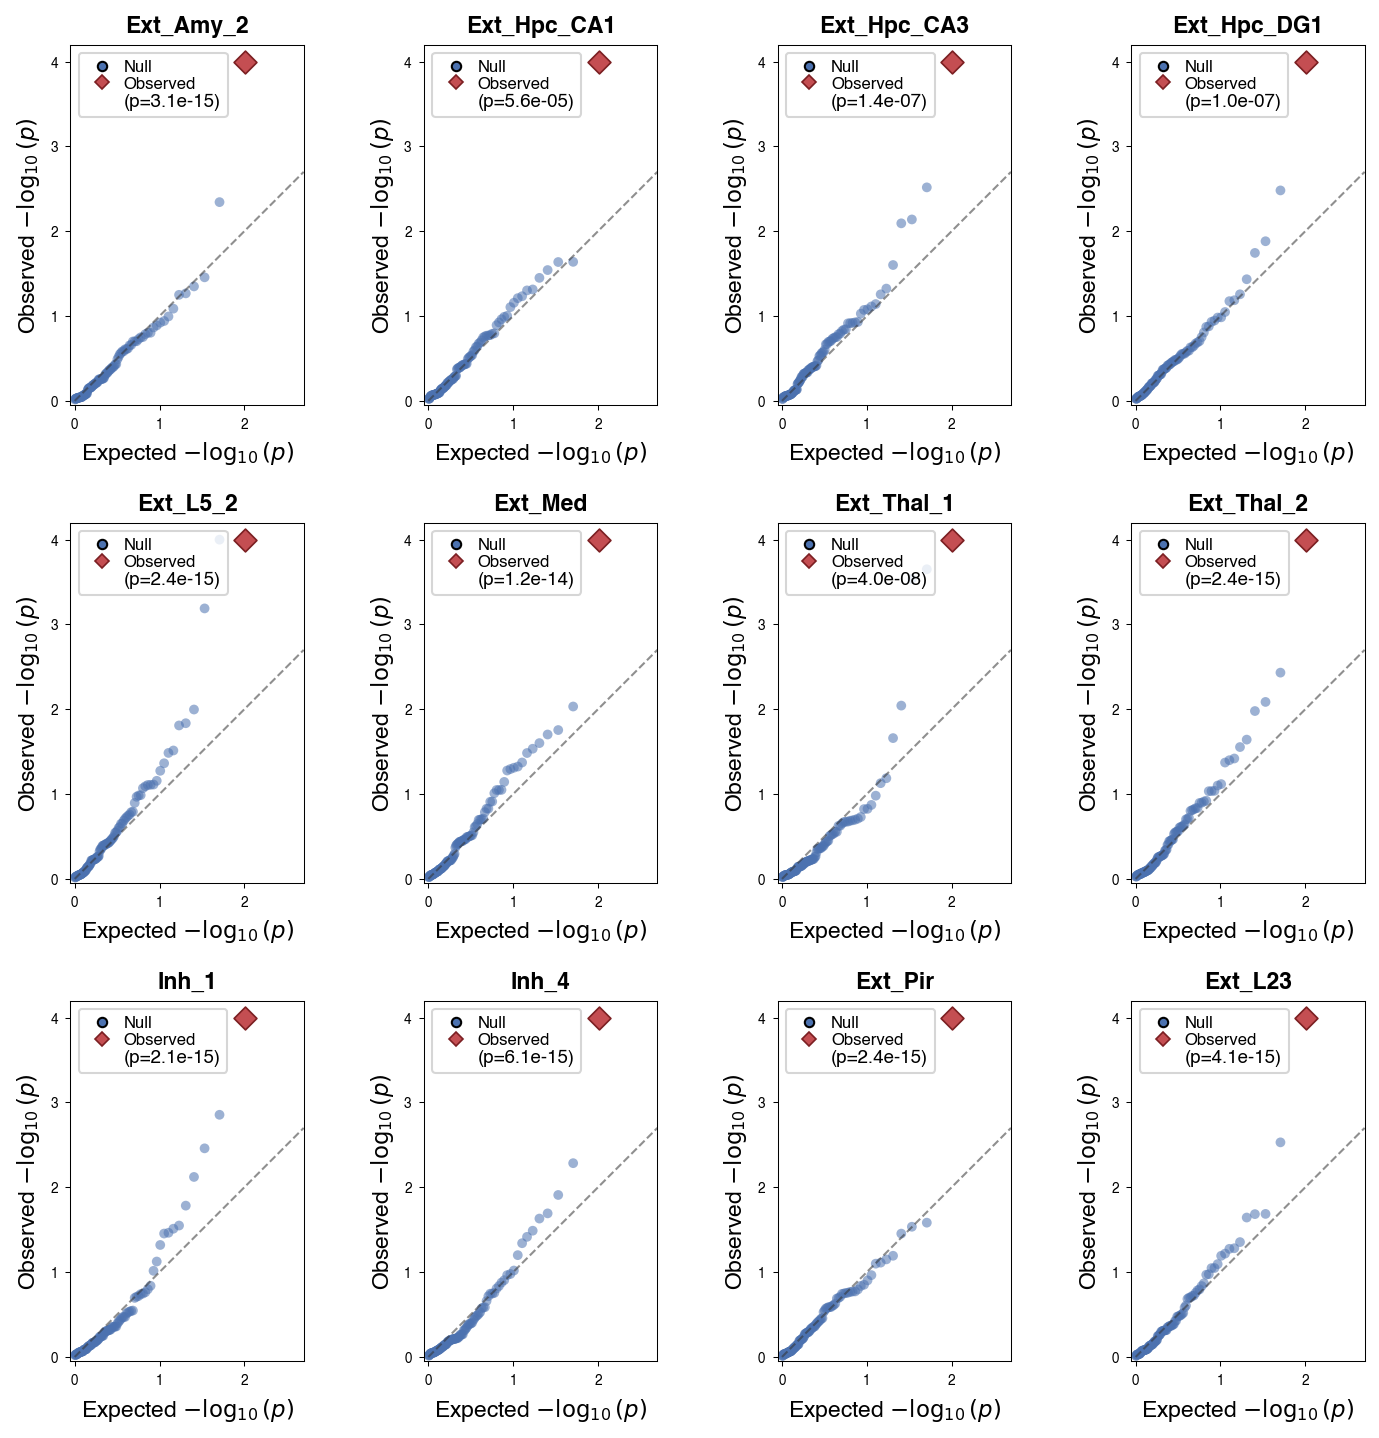

In [ ]:
from matplotlib.lines import Line2D

def qqplot_dist(
    null_pval_path, real_results=None, celltype_list=None,
    pval_range=(10**-3.5, 1.0), max_cols=4, figsize_cell=(3.2, 3.2),
    save_path=None,
):
    pval_min, pval_max = pval_range
    safe_log = lambda x: -np.log10(np.clip(x, pval_min, pval_max))

    df_null = (null_pval_path if isinstance(null_pval_path, pd.DataFrame)
               else pd.read_csv(null_pval_path, index_col=0))
    df_real = real_results if isinstance(real_results, pd.DataFrame) else (
        pd.read_csv(real_results, index_col=0) if isinstance(real_results, str) else None
    )

    cts     = [ct for ct in (celltype_list or df_null.columns) if ct in df_null.columns]
    n_ct    = len(cts)
    n_cols  = min(n_ct, max_cols)
    n_rows  = int(np.ceil(n_ct / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(figsize_cell[0]*n_cols, figsize_cell[1]*n_rows),
                             squeeze=False)

    NULL_COLOR = '#4C72B0'
    OBS_COLOR  = '#C44E52'
    lim  = -np.log10(pval_min) * 1.05
    ticks = list(range(0, int(np.floor(-np.log10(pval_min))) + 1,
                       max(1, int(np.floor(-np.log10(pval_min))) // 4)))

    for idx, ct in enumerate(cts):
        ax     = axes[idx // n_cols, idx % n_cols]
        null_p = df_null[ct].dropna().values
        n_null = len(null_p)

        has_real = df_real is not None and ct in df_real.index
        if has_real:
            real_p  = float(df_real.loc[ct, 'analytic_pval'])
            emp_p   = float(df_real.loc[ct, 'empirical_pval'])
            all_p   = np.concatenate([null_p, [real_p]])
            is_real = np.array([False]*n_null + [True])
        else:
            all_p, is_real = null_p.copy(), np.zeros(n_null, dtype=bool)

        order    = np.argsort(all_p)
        p_sorted = all_p[order]
        r_sorted = is_real[order]
        n        = len(p_sorted)
        exp_log  = safe_log(np.arange(1, n+1) / (n+1))
        obs_log  = safe_log(p_sorted)

        x_max = 2.5
        x_lim = x_max * 1.08
        ax.plot([0, min(x_lim, lim)], [0, min(x_lim, lim)],
                color='#333333', lw=1.0, ls='--', alpha=0.55)
        ax.scatter(exp_log[~r_sorted], obs_log[~r_sorted],
                   s=22, alpha=0.55, color=NULL_COLOR, edgecolors='none')
        if np.any(r_sorted):
            ax.scatter(float(exp_log[r_sorted][0]), float(obs_log[r_sorted][0]),
                       s=60, color=OBS_COLOR, edgecolors='#7B1F22',
                       linewidths=0.8, zorder=5, marker='D')

        handles = [Line2D([0],[0], marker='o', color='none',
                          markerfacecolor=NULL_COLOR, markersize=4.5, label='Null')]
        if has_real:
            handles += [
                Line2D([0],[0], marker='D', color='none', markerfacecolor=OBS_COLOR,
                       markersize=4.5, markeredgecolor='#7B1F22', markeredgewidth=0.8,
                       label='Observed'),
                Line2D([0],[0], color='none', label=f'(p={real_p:.1e})')
            ]
        leg = ax.legend(handles=handles, fontsize=8, loc='upper left',
                        framealpha=0.8, edgecolor='#CCCCCC', borderpad=0.4,
                        handletextpad=0.3, labelspacing=0.1)
        if has_real: leg.get_texts()[-1].set_fontsize(9)

        ax.set_xlim(-0.05, x_lim); ax.set_ylim(-0.05, lim)
        x_ticks = [t for t in ticks if t <= x_lim + 0.1]
        ax.set_xticks(x_ticks); ax.set_yticks(ticks)
        ax.set_aspect('equal')
        ax.set_xlabel('Expected $-\\log_{10}(p)$', fontsize=11, labelpad=4)
        ax.set_ylabel('Observed $-\\log_{10}(p)$',  fontsize=11, labelpad=4)
        ax.set_title(ct, fontsize=11, fontweight='bold', pad=6)

    for idx in range(n_ct, n_rows * n_cols):
        axes[idx // n_cols, idx % n_cols].set_visible(False)

    fig.tight_layout(w_pad=1.5, h_pad=1.8)
    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f'Saved to {save_path}')
    return fig

CT_PLOT = [
    'Ext_Amy_2', 'Ext_Hpc_CA1', 'Ext_Hpc_CA3', 'Ext_Hpc_DG1',
    'Ext_L5_2',  'Ext_Med',     'Ext_Thal_1',  'Ext_Thal_2',
    'Inh_1',     'Inh_4',       'Ext_Pir',     'Ext_L23',
]

fig_qq = qqplot_dist(
    null_pval_path = NULL_PVAL_V3,
    real_results   = df_results_v3,
    celltype_list  = CT_PLOT,
    pval_range     = (1e-4, 1.0),
    max_cols       = 4,
    figsize_cell   = (2.4, 3.2),
    save_path      = str(OUT_DIR / 'qqplot_dist_kernel.pdf'),
)
plt.show()

Saved to /import/home2/share/yqzeng/MacSGP/revision/vis/1.6/qqplot_dist_kernel_mainfig.pdf


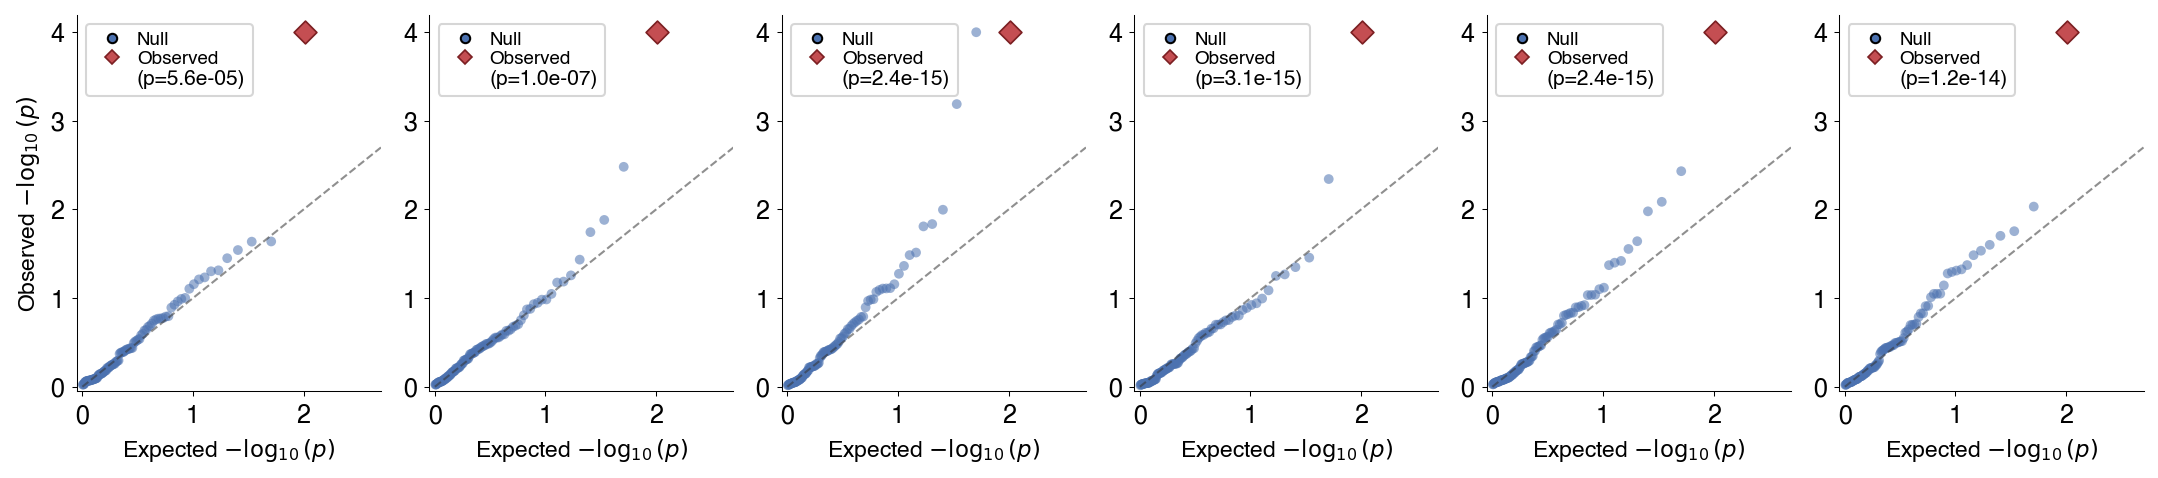

In [ ]:
from matplotlib.lines import Line2D

def qqplot_dist(
    null_pval_path, real_results=None, celltype_list=None,
    pval_range=(10**-3.5, 1.0), max_cols=4, figsize_cell=(3.2, 3.2),
    save_path=None,
):
    pval_min, pval_max = pval_range
    safe_log = lambda x: -np.log10(np.clip(x, pval_min, pval_max))

    df_null = (null_pval_path if isinstance(null_pval_path, pd.DataFrame)
               else pd.read_csv(null_pval_path, index_col=0))
    df_real = real_results if isinstance(real_results, pd.DataFrame) else (
        pd.read_csv(real_results, index_col=0) if isinstance(real_results, str) else None
    )

    cts     = [ct for ct in (celltype_list or df_null.columns) if ct in df_null.columns]
    n_ct    = len(cts)
    n_cols  = min(n_ct, max_cols)
    n_rows  = int(np.ceil(n_ct / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(figsize_cell[0]*n_cols, figsize_cell[1]*n_rows),
                             squeeze=False)

    NULL_COLOR = '#4C72B0'
    OBS_COLOR  = '#C44E52'
    lim  = -np.log10(pval_min) * 1.05
    ticks = list(range(0, int(np.floor(-np.log10(pval_min))) + 1,
                       max(1, int(np.floor(-np.log10(pval_min))) // 4)))

    for idx, ct in enumerate(cts):
        ax     = axes[idx // n_cols, idx % n_cols]
        null_p = df_null[ct].dropna().values
        n_null = len(null_p)

        has_real = df_real is not None and ct in df_real.index
        if has_real:
            real_p  = float(df_real.loc[ct, 'analytic_pval'])
            emp_p   = float(df_real.loc[ct, 'empirical_pval'])
            all_p   = np.concatenate([null_p, [real_p]])
            is_real = np.array([False]*n_null + [True])
        else:
            all_p, is_real = null_p.copy(), np.zeros(n_null, dtype=bool)

        order    = np.argsort(all_p)
        p_sorted = all_p[order]
        r_sorted = is_real[order]
        n        = len(p_sorted)
        exp_log  = safe_log(np.arange(1, n+1) / (n+1))
        obs_log  = safe_log(p_sorted)

        x_max = 2.5
        x_lim = x_max * 1.08
        ax.plot([0, min(x_lim, lim)], [0, min(x_lim, lim)],
                color='#333333', lw=1.0, ls='--', alpha=0.55)
        ax.scatter(exp_log[~r_sorted], obs_log[~r_sorted],
                   s=22, alpha=0.55, color=NULL_COLOR, edgecolors='none')
        if np.any(r_sorted):
            ax.scatter(float(exp_log[r_sorted][0]), float(obs_log[r_sorted][0]),
                       s=60, color=OBS_COLOR, edgecolors='#7B1F22',
                       linewidths=0.8, zorder=5, marker='D')

        handles = [Line2D([0],[0], marker='o', color='none',
                          markerfacecolor=NULL_COLOR, markersize=4.5, label='Null')]
        if has_real:
            handles += [
                Line2D([0],[0], marker='D', color='none', markerfacecolor=OBS_COLOR,
                       markersize=4.5, markeredgecolor='#7B1F22', markeredgewidth=0.8,
                       label='Observed'),
                Line2D([0],[0], color='none', label=f'(p={real_p:.1e})')
            ]
        leg = ax.legend(handles=handles, fontsize=9, loc='upper left',
                        framealpha=0.8, edgecolor='#CCCCCC', borderpad=0.4,
                        handletextpad=0.3, labelspacing=0.1)
        if has_real: leg.get_texts()[-1].set_fontsize(10)

        ax.set_xlim(-0.05, x_lim); ax.set_ylim(-0.05, lim)
        x_ticks = [t for t in ticks if t <= x_lim + 0.1]
        ax.set_xticks(x_ticks); ax.set_yticks(ticks)
        ax.tick_params(labelsize=12)
        #ax.set_aspect('equal')
        ax.set_xlabel('Expected $-\\log_{10}(p)$', fontsize=11, labelpad=4)
        if idx % n_cols == 0:
            ax.set_ylabel('Observed $-\\log_{10}(p)$',  fontsize=11, labelpad=4)
        #ax.set_title(ct, fontsize=11, fontweight='bold', pad=6)

        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    for idx in range(n_ct, n_rows * n_cols):
        axes[idx // n_cols, idx % n_cols].set_visible(False)

    fig.tight_layout(w_pad=1.5, h_pad=1.8)
    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f'Saved to {save_path}')
    return fig

CT_PLOT = [
    'Ext_Hpc_CA1', 'Ext_Hpc_DG1',
    'Ext_L5_2',  'Ext_Amy_2', 'Ext_Thal_2','Ext_Med',  
]

fig_qq = qqplot_dist(
    null_pval_path = NULL_PVAL_V3,
    real_results   = df_results_v3,
    celltype_list  = CT_PLOT,
    pval_range     = (1e-4, 1.0),
    max_cols       = 6,
    figsize_cell   = (2.4, 3.2),
    save_path      = str(OUT_DIR / 'qqplot_dist_kernel_mainfig.pdf'),
)
plt.show()